## Create a 2D netCDF file 

A flexible notebook to convert data files into netCDF format for upload to Datalakes. This is for 2D data where a single data file contains multiple values of dimension1 (e.g. a CTD profile where various value pressure measurements are repeated over time). 

If you are not sure how many dimensions your data has, please refer to the netCDF_README file.

This python notebook is designed to be flexible to handle various different types of data. Thus, it requires user entry into a few files to provide information about the data. 

In [1]:
# import the needed libraries
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import csv
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import warnings
from collections import defaultdict
import json
# just for plotting at the end
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

In [7]:
# import the functions that exist in the folder
from utils import find_file, extract_identifier_from_pattern, sanitize_name, combine_date_time, files_to_process_1d

__________

### Step 1: what format is your data?

**NOTE:** We are assuming that one of your dimensions is time. The other dimension (we will call dimension1) has multiple values per file. Each file contains repeated downcasts (or cycles, e.g. depth/pressure = 1.0 appears multiple times in each file). We assume the start of each cycle begins with the lowest dimension1 value (e.g. pressure = 1.0) and 'descends' to the maximum (e.g. pressure = 10.0), then resets. Each reset marks the start of a new cycle.  


Let's collect some information about your data files. 

In [3]:
# What is the variable name of dimension1? (e.g. depth, water_pressure, ...) no spaces
dimension1_name = 'press'

# How are cycles identified in your file? 
# OPTION A: there is an explicit column that denotes the cycle shift (e.g. profile_id). 
# Set cycle_id_column to the name of the column in the file
# OPTION B: There is no explicit column in the file that denotes this. 
# Cycles are detected automatically whenever dimension1 resets to the min value. Set cycle_id_column = None
cycle_id_column = 'profile_id' 

#### Time window assignment
Between the end of one cycle and the start of the next there is a gap with no
new measurements.  During that gap each pressure level is assigned the value
it had at the *start* of the most recent cycle (i.e. the measurement taken
at that pressure level during the last downcast is held constant).
This is done automatically – no action needed here.

---------

### Step 2: Find all the data files

Migrate all your data into the data folder: 'data/input/L0'

In [4]:
# the working directory is the folder that contains the full repo:
working_directory = Path.cwd().parent
# the input data directory is where all your data should be:
inputdata_directory = working_directory / 'data/input/L0_2dB'
# the script directory is where all the scripts are located:
script_directory = working_directory / 'scripts'

# What is the file naming convention? (need help with this - see README.txt)
data_file_pattern = '*.txt'

In [8]:
### User input not required in this cell ###

# find all the data files you have put in the data folder (L0):
file_list = files_to_process_1d(inputdata_directory, data_file_pattern)  

Total files found: 5


In [13]:
### This will overwrite an existing 'datafile_information.csv' if you are re-running this script ###
### User input not required in this cell ###

## save this info to a csv file
dfile_output_file = inputdata_directory.parent / 'datafile_information.csv'
## comment below if you are re-running this scripts
dfile_metadata.to_csv(dfile_output_file, index = False)

--------

### Step 3: information about the format of your data files

Please fill in the below with the needed information on the format of your data file:

In [14]:
datafile_attributes = {   
            # Data collection time period (YYYY,mm,dd,hh,min,ss):
            "start_time": datetime(2020,7,20,0,0,0),
            "end_time": datetime(2020,8,20,0,0,0),

            # What line/row are the columns named? using python numbering, row0 = first line in file, row1 = second line in file, etc.
            "header_row": 0,        
    
            # Are there lines/rows between the header and when the data starts (e.g. blank rows or lines with other non-data information?)
            # how many?
            "droprows": 0, 

            # What is the separator in your data file (e.g. comma = ',', tab = '\t', space = ' ', semicolon = ';', etc)?
            "separator": ',',
    
            # What is the fill value/missing value number? (e.g. '999', 'NaN', 'NAN') 
            "_FillValue": ' ',

            # What are your date/time column(s) named in your data file? 
            # Ordered from largest to smallest (e.g. Date, Time OR Year, Month, Day, etc.) NOT in the order they are in your datafile
            "time_columns": ['timestamp'], 

            # Do your data files collect data in UTC time? Enter the time shift in hours or 0 if they are already in UTC:
            "time_shift": 0, 

            # No header? Only fill out if no header in files exists. What columns of data are you interested in? 
            # Include the date/time column. Use python number, first column = 0, and so on.
            # If the header in the file exists, just leave blank
            # Only include variables/dimensions you are interested in processing:
            "col_nums": [0,2,3,4],
    
            # What are the variable names in the data files, including the names of the time/date columns? 
            # We will pull the variables in your file based on these names (ensure they are labelled the same as in the data files)
            # Only include variables you are interested in processing:
            "var_names": ['timestamp', 'press', 'temp', 'cond'], 
        }

In [17]:
### User input not required in this cell ###

# Convert start and end time to seconds since 1970 for netcdf format
sec_start_time = datafile_attributes["start_time"].timestamp()
sec_end_time = datafile_attributes["end_time"].timestamp() 

# Let's just add the dimension1 name into the datafile_attributes dictionary for later
datafile_attributes["dimension1_name"] = dimension1_name
datafile_attributes["cycle_id_column"] = cycle_id_column

In [11]:
### User input not required in this cell ###
### This will create/overwrite the variables.csv file if you already have one ###

# Create a variable mapping file:
var_output = inputdata_directory.parent / 'variables.csv'

# Do not edit the below:
# Column names in this file
headers = ['var_name', 'dim', 'unit', 'long_name', 'min', 'max']

# add in dimension1 to this file
dim1_metadata = {'var_name': dimension1_name, 
                 'dim': f'({dimension1_name},)',
                 'unit': '',
                 'long_name': '',
                 'min': '',
                 'max': ''}

# input the time metadata that we already know
time_metadata = {'var_name':'time',
                 'dim': '(time,)',     #var is dependent on this variable
                 'unit': 'seconds since 1970-01-01 00:00:00',
                 'long_name': 'time',
                 'min': sec_start_time - 86400,
                 'max': sec_end_time + 86400}

# let's make the variable file
with open(var_output, mode = 'w', newline='') as file:
     writer = csv.DictWriter(file, fieldnames=headers)
     writer.writeheader()
    
     # write time 
     writer.writerow(time_metadata)
     # write the other dimension in
     writer.writerow(dim1_metadata)
    
     # manage the overlapping time entries if they exist
     list3 = [item for item in datafile_attributes["var_names"] if item not in datafile_attributes["time_columns"] and sanitize_name(item) != dimension1_name]
    
     # write in the other variables
     for name in list3:
         #remove any spaces as needed
         name = sanitize_name(name)
         row = {
             'var_name': name.lower(),
             'dim':'',
             'unit': '',
             'long_name': '',
             'min':'',
             'max': ''}
         writer.writerow(row)

print(f"variables.csv written to {var_output}")
print("Please open and fill in the unit / long_name / min / max columns.")

variables.csv written to /Users/knappeel/Documents/coding/datalakes/data_convert/data/input/variables.csv
Please open and fill in the unit / long_name / min / max columns.


### Step 5: edit the variable file

In your data/input folder there is now a file labeled 'variables.csv'. This information is needed for the netCDF metadata. 

**Check the information in this file and fill in the blank columns for your additional variables. Do not edit the time row.**

Info about this file:
* var_name = shorthand name for the variable (ensure there are no spaces in the var_name)
* dim = the dimension(s) this is variable is dependent on, set up as (dim1, dim2, ...) (see README.md Step 5 for more information, if you are uncertain about this)
* unit = the units (e.g. temp = degrees C etc)
* long_name = the full name for the variable (can be the same as var_name). See CF conventions, linked below, if uncertain.
* min = expected minimum value
* max = expected maximum value


CF naming conventions: [ https://cfconventions.org/Data/cf-standard-names/27/build/cf-standard-name-table.html ]

CF guidelines for construction of names: [ https://cfconventions.org/Data/cf-standard-names/docs/guidelines.html ]

---------------------------

### Step 6: Metadata

For this, you can enter the metadata here manually or use the metadata generator script. For manually entering run OPTION A, or for using a generated metadata file, use OPTION B.

*Recommended*: The metadata generator can be found on Renku, ready to use, here: [https://renkulab.io/p/ellen.knappe/datalakes-streamlit]. This will create a JSON file in the DataCite format, and should be included in your data upload. Alternatively, you can run it on your local machine by forking the repo from the Eawag Gitlab [ https://gitlab.eawag.ch/ellen.knappe/datalakes_streamlit ] or Github [ https://github.com/eknappe/metadata_generator ]. We recommend using the DataCite format because this format is interoperable, machine-readable, and recommended by the ETH Domain.

We will be using ACDD conventions for the netCDF. See here for more info: [ https://wiki.esipfed.org/Attribute_Convention_for_Data_Discovery_1-3 ].

Once you generate the metadata file, put it in the working_directory.

**OPTION A: No metadata file? Input information here and skip to Step 7. If you have a metadata file, skip this cell.** 

In [12]:
## SKIP THIS SECTION IF YOU CREATED A METADATA FILE ##
# else, input the required fields
general_attributes = {
            "title": " ",
            "creator_name": " ",
            "institution": " ",
            "keywords": "[keyword1,keyword2,..] ",
            "Conventions": "ACDD-1.3",
            "description": " ", #abstract/description of your data
            "source": " ", #add in the name of the lakes here and any other project info needed
            "license": " "
        }

__OPTION B: I have a metadata file:__

In [9]:
# Do you have a metadata file? 

# we recommend putting it the top level directory, e.g. the working_directory that was set at the start of this notebook 
# else define it here
file_location = working_directory
print(f"This is where you should put your metadata file: {working_directory}")

This is where you should put your metadata file: /Users/knappeel/Documents/coding/datalakes/data_convert


In [10]:
## SKIP THIS CELL AND THE NEXT CELL IF YOU ADDED METADATA MANUALLY in the above cell ##

# read in the json metadata file
jfilename = 'your_metadata_file.json'

jfilename = file_location / jfilename

In [11]:
## SKIP THIS CELL AND THE NEXT CELL IF YOU ADDED METADATA MANUALLY ##
## User input not required in this cell ##

# Read in the metadata file provided
with open(jfilename, mode = 'r', encoding = "utf-8") as read_file:
    metadata_json = json.load(read_file)

# extract the needed information from the json metadata file 
title = metadata_json['data']['attributes']['titles'][0]['title']
creator_name = metadata_json['data']['attributes']['creators'][0]['name']
institution = metadata_json['data']['attributes']['creators'][0]['affiliation'][0]['name']
keywords = ', '.join([key['subject'] for key in metadata_json['data']['attributes']['subjects']]) #extracts the keywords if there are multiple
description = metadata_json['data']['attributes']['descriptions'][0]['description']
source =', '.join([geo['geoLocationPlace'] for geo in metadata_json['data']['attributes']['geoLocations']]) #extracts the location if there are multiple
license = metadata_json['data']['attributes']['rightsList'][0]['rights']

# make a dictionary for ease of adding it to the netCDF file
general_attributes = {
            "title": title,
            "creator_name": creator_name,
            "institution": institution,
            "keywords": keywords,
            "Conventions": "ACDD-1.3",
            "description": description,
            "source": source, 
            "license": license
        }

print(general_attributes)

{'title': 'Test: Thermistor data from Jemina', 'creator_name': 'Ellen Knappe', 'institution': 'Lib4RI - Library for the Research Institutes within the ETH Domain: Eawag\\, Empa\\, PSI & WSL', 'keywords': 'temperature, depth', 'Conventions': 'ACDD-1.3', 'description': 'This is some test data kindly provided by Jemima to test this all out. ', 'source': 'Lake Zug', 'license': 'CC BY 4.0'}


______________

### Step 7: read in all the data files

It's show time. 

This is the main processing step. For each file it will:
1. Parse the data and conert timesteps into Unix seconds.
2. Identify the cycles (either from the explicit ID columns or by detecting when dim1 resets).
3. Forward fill each var into the time gaps between cycles.
4. Build an xr.Dataset with dimensions (time, dim1). 

In [27]:
# no user input needed for this cell #

dim1_name = datafile_attributes["dimension1_name"]
cycle_col = datafile_attributes["cycle_id_column"]

# accumulate all the files
# depending on how many files, this could take a minute
all_datasets = []

# loop through all the files listed
for file in file_list:
    
    #read in the file, only import columns based on names
    cols_to_load = list(datafile_attributes["var_names"])
    if cycle_col and cycle_col not in cols_to_load:
        cols_to_load.append(cycle_col)
   
    if datafile_attributes["header_row"] is None:
        data = pd.read_csv(file, sep = datafile_attributes["separator"], header = None, 
                           usecols = datafile_attributes["col_nums"])
        #rename the positional columns to the co
        data.columns = datafile_attributes["var_names"]
    else:
        data = pd.read_csv(file, sep = datafile_attributes["separator"], header = datafile_attributes["header_row"], 
                   usecols = cols_to_load) 

    #if there are rows between the header and the data, we will drop those
    #if there are none, then nothing will happen
    if datafile_attributes["droprows"] > 0:
        for ii in range(0, datafile_attributes["droprows"]):
            data = data.drop(index=ii)
    
    # convert the time column(s) into the correct format
    # this will convert the date column into seconds since 1970 (Unix format)
    data_with_time = combine_date_time(data, datafile_attributes["time_columns"], datafile_attributes["separator"])
    
    #apply time shift if needed
    data_with_time["time"] = data_with_time["time"] + (datafile_attributes["time_shift"]*3600)

    #identify the cycles 
    if cycle_col and cycle_col in data.columns:
        # use the explicit cycle/profile ID column from the file
        data_with_time["_cycle"] = data_with_time[cycle_col].values

    else:
        # auto-detect: a new cycle starts whenever dimension1 resets back to
        # (or below) the value it had on the very first row of the file
        cycle_num = 0
        cycle_ids = []
        for i, val in enumerate(data_with_time[dim1_name]):
            if i > 0 and val <= data_with_time[dim1_name].iloc[0]:
                cycle_num += 1   # dimension1 has reset to new cycle
            cycle_ids.append(cycle_num)
        data["_cycle"] = cycle_ids    
    
    #forward fill the variables 

    #step 1 collect the full set of timestamps and dim levels
    all_times = np.sort(data_with_time["time"].unique())
    dim_levels = np.array(sorted(data_with_time[dim1_name].unique()), dtype=float)

    # only the data variable (no time or dim1)
    data_vars = [
        c for c in data_with_time.columns
        if c not in {"time", dim1_name, "_cycle"}
        and c not in datafile_attributes["time_columns"]
        and c != cycle_col
    ]

    # create index lookups for fast array placement
    time_index = {t: i for i, t in enumerate(all_times)}
    dim_index  = {p: j for j, p in enumerate(dim_levels)}

    # Step 4: initialise empty 2-D arrays (NaN) — one per data variable
    arrays = {var: np.full((len(all_times), len(dim_levels)), np.nan)
              for var in data_vars}

    # place each measured value into its correct (time, dim1) slot
    for _, row in data_with_time.iterrows():
        ti = time_index[row["time"]]
        di = dim_index[row[dim1_name]]
        for var in data_vars:
            arrays[var][ti, di] = row[var]

    #forward-fill along the time axis — carries each value forward
    for var in data_vars:
        df_tmp = pd.DataFrame(arrays[var], index=all_times, columns=dim_levels)
        df_tmp.ffill(axis=0, inplace=True)
        arrays[var] = df_tmp.values

    #ASSEMBLE!!
    # build the xr data set for the file: dims = time, dim1
    ds_file = xr.Dataset(
        {
            var: xr.DataArray(arrays[var],dims=["time", dim1_name],)
            for var in data_vars
        },
        coords={"time": all_times,
            dim1_name: dim_levels,
        },
    )

    all_datasets.append(ds_file) #make one super dataset with everything

# edit the super dataset and format it correctly
full_ds = xr.concat(all_datasets, dim = "time", join = "outer") # expand along dim1
full_ds = full_ds.sortby(["time", dim1_name])

# check the files don't have overlap
time_counts = pd.Series(full_ds.time.values).duplicated(keep=False)
if time_counts.any():
    warnings.warn(
        f"WARNING: overlapping time values detected across files."
        f"Review your input files for overlapping data. Keeping the first occurrence.", stacklevel =2)

# add in the attributes (the metadata info into the netCDF)
full_ds.attrs = general_attributes

print('Files compiled into variable called full_ds')

Files compiled into variable called full_ds


### Step 8: check the data

Now, let's check the data. First, just check out the netCDF information. 

In [28]:
print(full_ds)

<xarray.Dataset> Size: 104MB
Dimensions:  (time: 40195, press: 161)
Coordinates:
  * press    (press) float64 1kB 1.0 1.1 1.2 1.3 1.4 ... 16.7 16.8 16.9 17.0
  * time     (time) int64 322kB 1595407138 1595407141 ... 1598217302 1598217305
Data variables:
    temp     (time, press) float64 52MB 23.69 nan nan nan ... 7.455 7.447 7.22
    cond     (time, press) float64 52MB 0.42 nan nan nan ... 0.345 0.345 0.343
Attributes:
    title:          
    creator_name:   
    institution:    
    keywords:      [keyword1,keyword2,..] 
    Conventions:   ACDD-1.3
    description:    
    source:         
    license:        


Now let's plot the data to check it out. 

In [29]:
# name of variable would you like to plot (as listed in the netCDF)
variabletoplot = "temp"

# set some bounds so the colorbar makes more sense 
# feel free to edit to your needs, but we find these bounds work well for visualizing the data
data = full_ds[variabletoplot].values

# going to remove the "tails" of data to define the colorbar, this is just for plotting, it does not affect the data
vmin = np.nanpercentile(data, 5)
vmax = np.nanpercentile(data, 95)

# font size
lsize = 20

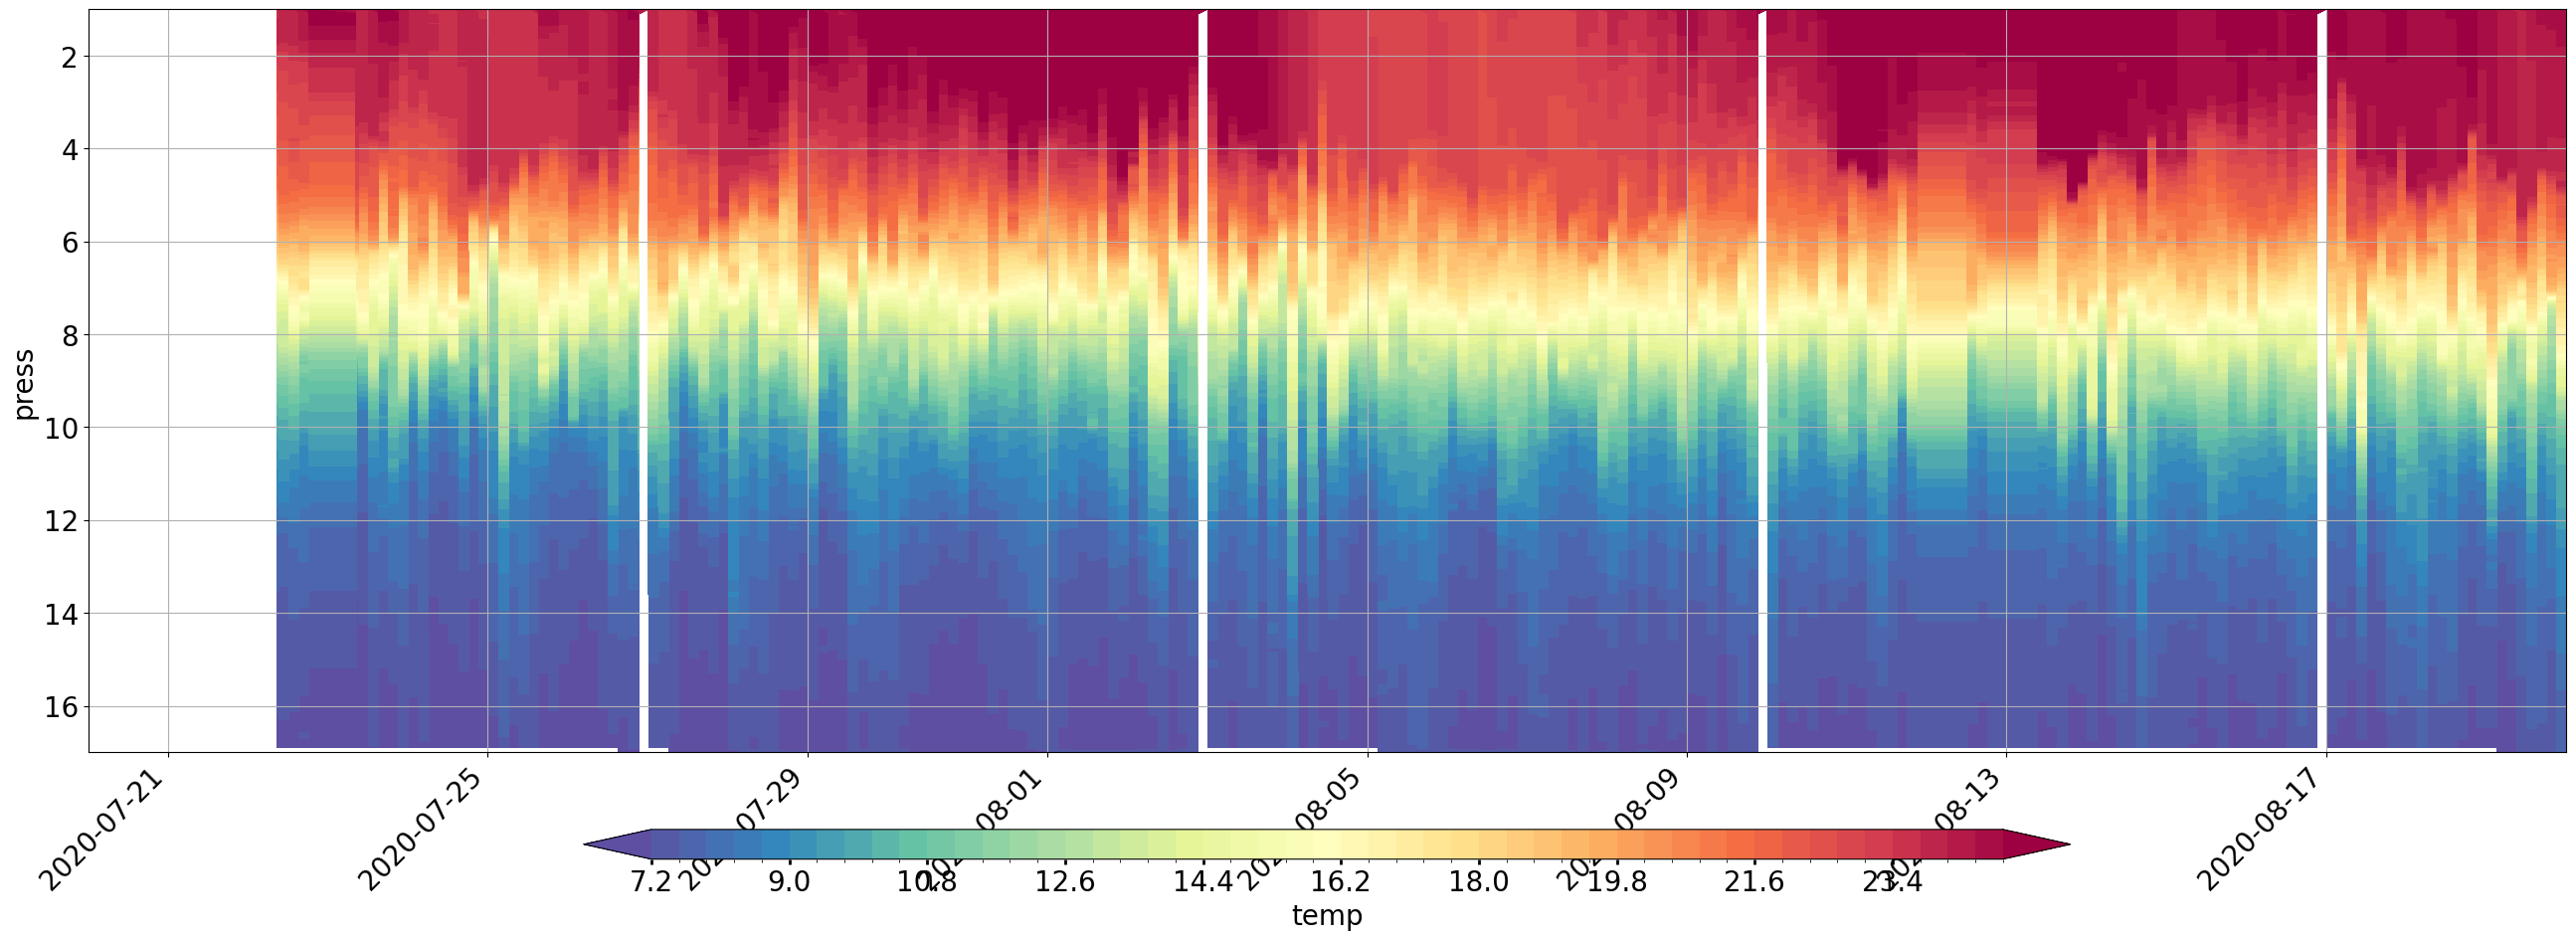

In [30]:
# user input not needed in this cell 
# plot should show up below this cell

# Modified from Jemima Rama's code. Thanks, Jemina!

# convert unix timestamps to datetime64 for plotting purposes - so folks can read them :)
plot_ds = full_ds.assign_coords(time=pd.to_datetime(full_ds["time"].values, unit="s"))

# create the plot
fig, ax = plt.subplots(1, figsize=(26, 10))
contour = plot_ds[variabletoplot].plot.contourf(x = "time", y = dim1_name, #set the axes
    levels=50, cmap='Spectral_r', add_colorbar=False, vmin=vmin, vmax=vmax)

# invert the y-axis since the depths are depths from the surface, can remove this is your  
ax.invert_yaxis()  

# format xaxis as readable dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=45, ha='right')

ax.set_xlim(pd.Timestamp(datafile_attributes['start_time']), pd.Timestamp(datafile_attributes['end_time']))

plt.grid('minor')
ax.tick_params(axis='both', which='major', labelsize=lsize)  # adjust parameters as needed

# add horizontal colorbar
cbar = fig.colorbar(contour, ax=ax, orientation='horizontal', pad=0.08, shrink=0.6, aspect=50)

# adjust the colorbar's tick parameters
cbar.ax.tick_params(labelsize=lsize, width=2)  # increase label size and tick width
cbar.ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
cbar.set_label(variabletoplot, fontsize=lsize)

plt.ylabel(dim1_name, fontsize=lsize)
plt.xlabel('', fontsize=lsize)

plt.tight_layout()

### Step 9: Save the data! 

In [42]:
filename_prefix= 'your_dataset_name_here'
save_directory = working_directory / 'data/output'

# Datalakes format has a netcdf file for each month, so that's what we will do
# note if you just want a singular netcdf, you can use full_ds.to_netcdf(filelocation/filename)

# times is recorded in seconds since 1970, decode for labelling
decoded_times = pd.to_datetime(full_ds.time.values, unit='s')

# group by year-month string
labels = pd.Series(decoded_times).dt.strftime("%Y_%m").values

for label in np.unique(labels):
    mask = labels == label
    ds_month = full_ds.isel(time = mask)

    #get the first day of data in the month for labelling
    first_day = decoded_times[mask].min().day

    filename = os.path.join(save_directory, f"{filename_prefix}_{label}_{first_day:02d}.nc")
    ds_month.to_netcdf(filename)
    print(f"Saved {filename}")

Saved /Users/knappeel/Documents/coding/datalakes/data_convert/data/output/testing_filename_2025_01_15.nc
Saved /Users/knappeel/Documents/coding/datalakes/data_convert/data/output/testing_filename_2025_02_01.nc
Saved /Users/knappeel/Documents/coding/datalakes/data_convert/data/output/testing_filename_2025_03_01.nc
Saved /Users/knappeel/Documents/coding/datalakes/data_convert/data/output/testing_filename_2025_04_01.nc
